In [14]:
# Process GENCODE v50 translations
# Goal: keep only transcripts with transcript_type == "protein_coding"
# This removes NMD, non_stop_decay, protein_coding_LoF, IG/TR, and other non-standard coding-related biotypes.

from pathlib import Path
import gzip
import re

# Define project folders
project_dir = Path("/Users/richbaconburger/Desktop/humanpeptidome_JP_library")
proteome_dir = project_dir / "peptidome_proteomes"
gencode_dir = project_dir / "peptidome_library_construction" / "GENCODE"
gencode_dir.mkdir(parents=True, exist_ok=True)

# Define input files
# input_fasta contains all GENCODE pc_translations records, including non-protein_coding biotypes
# gtf_file contains transcript annotations, including transcript_type/biotype
input_fasta = proteome_dir / "1_peptidome_gencode.v50.pc_translations.fa.gz"
gtf_file = proteome_dir / "1_gencode.v50.annotation.gtf.gz"

# Define output file for protein_coding-only translations
output_fasta = gencode_dir / "gencode.v50.protein_coding.translations.fasta"

# GTF attributes look like: transcript_id "ENST..."; transcript_type "protein_coding";
# This regex extracts those key-value pairs from the attributes column
attr_re = re.compile(r'(\S+) "([^"]*)";')

# Read the GTF and collect transcript IDs whose transcript_type is exactly protein_coding
protein_coding_transcripts = set()

with gzip.open(gtf_file, "rt") as gtf:
    for line in gtf:
        # Skip GTF header/comment lines
        if line.startswith("#"):
            continue

        # GTF has 9 tab-separated columns; column 3 is feature type, column 9 is attributes
        fields = line.rstrip("\n").split("\t")

        # We only need transcript-level rows because they contain transcript_type
        if len(fields) < 9 or fields[2] != "transcript":
            continue

        # Parse the attributes column into a dictionary
        attrs = dict(attr_re.findall(fields[8]))

        # Keep only transcript IDs annotated as protein_coding
        if attrs.get("transcript_type") == "protein_coding":
            protein_coding_transcripts.add(attrs["transcript_id"])

# Read the GENCODE translation FASTA and keep only records whose ENST transcript ID
# is present in the protein_coding_transcripts set from the GTF
total = 0
kept = 0
write_record = False

with gzip.open(input_fasta, "rt") as inp, output_fasta.open("w") as out:
    for line in inp:
        # FASTA headers look like:
        # >ENSP...|ENST...|ENSG...|...
        if line.startswith(">"):
            total += 1

            # Extract ENST transcript ID from the second pipe-delimited field
            transcript_id = line[1:].split("|")[1]

            # Decide whether to write this FASTA record
            write_record = transcript_id in protein_coding_transcripts

            if write_record:
                kept += 1
                out.write(line)

        # Write sequence lines only if their header passed the filter
        elif write_record:
            out.write(line.upper())

# Print summary so we can confirm the expected GENCODE count
print(f"Total GENCODE translation records: {total:,}")
print(f"Kept protein_coding records: {kept:,}")
print(f"Output: {output_fasta}")

Total GENCODE translation records: 382,428
Kept protein_coding records: 278,455
Output: /Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/GENCODE/gencode.v50.protein_coding.translations.fasta


In [ ]:
# Peptidome cleanup for GENCODE protein_coding translations
#
# Important: keep naturally long proteins separate from short proteins that need XTEN padding.
# Shared XTEN padding can make unrelated short proteins look artificially similar during CD-HIT.
#
# Outputs:
# - long_unpadded_fasta: original protein_coding translations that are already >=64 aa
# - short_padded_fasta: original protein_coding translations that are 5-63 aa, padded to exactly 64 aa with XTEN
# - sequences shorter than 5 aa are removed

from pathlib import Path

# Define input and output files
gencode_dir = Path("/Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/GENCODE")

input_fasta = gencode_dir / "gencode.v50.protein_coding.translations.fasta"
long_unpadded_fasta = gencode_dir / "gencode.v50.protein_coding.long_unpadded.fasta"
short_padded_fasta = gencode_dir / "gencode.v50.protein_coding.short_XTEN_padded.fasta"

# XTEN linker used for N-terminal padding of short sequences (I got this sequence from John referring to Bodansky's AEGIS paper)
XTEN = "ATPESSGSETPGTSESATPESSGSEAPGTSTEPSEGSAPGSEPATSGSETPGTSESATP"

# Read FASTA records one at a time
def read_fasta(path):
    header, seq = None, []

    with path.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq)

                header, seq = line[1:], []

            elif line:
                seq.append(line)

        if header is not None:
            yield header, "".join(seq)

# Clean, filter, split, pad, and write FASTA records
total = removed = long_unpadded = short_padded = 0

with long_unpadded_fasta.open("w") as long_out, short_padded_fasta.open("w") as short_out:
    for header, seq in read_fasta(input_fasta):
        total += 1

        # Clean sequence text
        seq = seq.upper().replace("*", "")

        # Remove sequences shorter than 5 aa
        if len(seq) < 5:
            removed += 1
            continue

        # Keep proteins that are already at least 64 aa in an unpadded FASTA
        if len(seq) >= 64:
            long_unpadded += 1
            long_out.write(f">{header}\n{seq}\n")
            continue

        # Pad 5-63 aa proteins to exactly 64 aa using the end of the XTEN linker
        pad_len = 64 - len(seq)
        padded_seq = XTEN[-pad_len:] + seq
        padded_header = f"{header} | XTEN_Nterm_padded_to_64aa original_length={len(seq)}"
        short_padded += 1
        short_out.write(f">{padded_header}\n{padded_seq}\n")

# Print summary
print(f"Input records: {total:,}")
print(f"Removed <5 aa: {removed:,}")
print(f"Long unpadded proteins >=64 aa: {long_unpadded:,}")
print(f"Short XTEN-padded proteins 5-63 aa: {short_padded:,}")
print(f"Long/unpadded output: {long_unpadded_fasta}")
print(f"Short/padded output: {short_padded_fasta}")


Input records: 278,455
Removed <5 aa: 90
Long unpadded proteins >=64 aa: 268,980
Short XTEN-padded proteins 5-63 aa: 9,385
Long/unpadded output: /Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/GENCODE/gencode.v50.protein_coding.long_unpadded.fasta
Short/padded output: /Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/GENCODE/gencode.v50.protein_coding.short_XTEN_padded.fasta


Sequences below 64 aa: 9,475
Shortest sequence: 1 aa
Longest below 64 aa: 63 aa


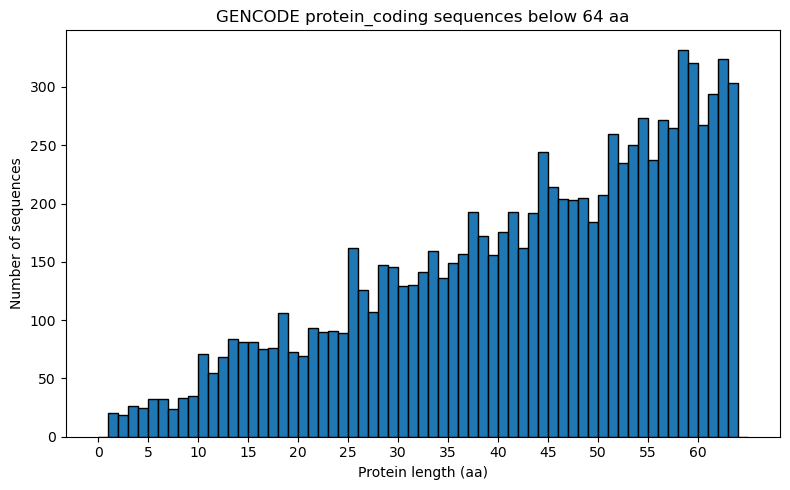

In [16]:
# Plot length distribution for original GENCODE protein_coding sequences below 64 aa
# This helps show how many proteins will need XTEN padding in the cleanup step.

from pathlib import Path
import matplotlib.pyplot as plt

# Use the original filtered FASTA from Cell 1, before cleanup/padding
gencode_dir = Path("/Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/GENCODE")
input_fasta = gencode_dir / "gencode.v50.protein_coding.translations.fasta"

# Read FASTA records one at a time
def read_fasta(path):
    header, seq = None, []

    with path.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq)

                header, seq = line[1:], []

            elif line:
                seq.append(line)

        if header is not None:
            yield header, "".join(seq)

# Collect sequence lengths below 64 aa
short_lengths = []

for header, seq in read_fasta(input_fasta):
    seq = seq.upper().replace("*", "")
    if len(seq) < 64:
        short_lengths.append(len(seq))

# Print summary stats
print(f"Sequences below 64 aa: {len(short_lengths):,}")

if short_lengths:
    print(f"Shortest sequence: {min(short_lengths)} aa")
    print(f"Longest below 64 aa: {max(short_lengths)} aa")

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(short_lengths, bins=range(0, 66), edgecolor="black")
plt.xlabel("Protein length (aa)")
plt.ylabel("Number of sequences")
plt.title("GENCODE protein_coding sequences below 64 aa")
plt.xticks(range(0, 65, 5))
plt.tight_layout()
plt.show()

In [17]:
%%bash

# GENCODE peptidome fragment generation
#
# We split the input before pepsyn/CD-HIT because XTEN-padded short proteins share artificial
# padding sequence. Long, naturally unpadded proteins use the standard 95% CD-HIT settings;
# short padded proteins are deduplicated only at 100% full-length identity.

cd "/Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/GENCODE"

# -----------------------------------------------------------------------------
# 1) Long proteins: real, unpadded sequences >=64 aa
#    These use standard 64-aa / 42-overlap tiling and 95% CD-HIT settings.
# -----------------------------------------------------------------------------

# Generate 64-aa peptides with 42-aa overlap from long unpadded GENCODE proteins
cat gencode.v50.protein_coding.long_unpadded.fasta \
| pepsyn x2ggsg - - \
| pepsyn tile -l 64 -p 42 - - \
| pepsyn disambiguateaa - - \
> gencode.v50.protein_coding.long_unpadded.w64s42.raw.tiles.fasta

# Generate C-terminal peptides separately to prevent C-terminal truncation
cat gencode.v50.protein_coding.long_unpadded.fasta \
| pepsyn x2ggsg - - \
| pepsyn ctermpep -l 64 - - \
| pepsyn disambiguateaa - - \
> gencode.v50.protein_coding.long_unpadded.w64.cterm.raw.tiles.fasta

# Deduplicate long-protein regular tiles using Bartley panseq-style CD-HIT settings
# -c 0.95 = 95% sequence identity
# -G 0 = local identity
# -A 53 = alignment must cover at least 53 aa
cd-hit -i gencode.v50.protein_coding.long_unpadded.w64s42.raw.tiles.fasta \
-o gencode.v50.protein_coding.long_unpadded.w64s42.cdhit_c95_A53.tiles.fasta \
-c 0.95 -G 0 -A 53 -M 0 -T 1 -d 0

# Deduplicate long-protein C-terminal tiles at 95% identity with FULL-LENGTH coverage.
# Following Mohan et al. 2018 / i-PanSeq, C-terminal peptides use full-length alignment
# (-aL 1.0 -aS 1.0) so the protein's terminal residues (C-terminal epitopes) are not lost.
cd-hit -i gencode.v50.protein_coding.long_unpadded.w64.cterm.raw.tiles.fasta \
-o gencode.v50.protein_coding.long_unpadded.w64.cterm.cdhit_c95_full_length.tiles.fasta \
-c 0.95 -G 0 -aL 1.0 -aS 1.0 -M 0 -T 1 -d 0

# -----------------------------------------------------------------------------
# 2) Short proteins: XTEN-padded sequences that are exactly 64 aa
#    These are deduplicated only at 100% full-length identity, so two short proteins
#    do not collapse merely because they share the same XTEN padding.
# -----------------------------------------------------------------------------

# Each short padded protein is already exactly 64 aa, so one tile captures the full construct.
# A separate C-terminal pepsyn step is not needed for this padded-only set.
cat gencode.v50.protein_coding.short_XTEN_padded.fasta \
| pepsyn x2ggsg - - \
| pepsyn tile -l 64 -p 42 - - \
| pepsyn disambiguateaa - - \
> gencode.v50.protein_coding.short_XTEN_padded.w64.raw.tiles.fasta

# Deduplicate padded short proteins only if the full 64-aa peptide is identical.
cd-hit -i gencode.v50.protein_coding.short_XTEN_padded.w64.raw.tiles.fasta \
-o gencode.v50.protein_coding.short_XTEN_padded.w64.cdhit_c100_full_length.tiles.fasta \
-c 1.0 -G 1 -aL 1.0 -aS 1.0 -M 0 -T 1 -d 0


tile: 268980seq [00:52, 5092.16seq/s]
ctermpep: 268980seq [00:02, 95765.26seq/s] 


Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 21:58:32
Command: cd-hit -i
         gencode.v50.protein_coding.long_unpadded.w64s42.raw.tiles.fasta
         -o
         gencode.v50.protein_coding.long_unpadded.w64s42.cdhit_c95_A53.tiles.fasta
         -c 0.95 -G 0 -A 53 -M 0 -T 1 -d 0

Started: Mon Jun 29 14:27:31 2026
                            Output                              
----------------------------------------------------------------
total seq: 5400190
longest and shortest : 64 and 64
Total letters: 345612160
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 1562M
Buffer          : 1 X 64M = 64M
Table           : 1 X 129M = 129M
Miscellaneous   : 68M
Total           : 1824M

Table limit with the given memory limit:
Max number of representatives: 4000000
Max number of word counting entries: 82032000

comparing sequences from          0  to    1281750
..........    10000  finished       1289  clusters
..........    20000  finished       

tile: 9385seq [00:00, 91772.13seq/s]


Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 21:58:32
Command: cd-hit -i
         gencode.v50.protein_coding.short_XTEN_padded.w64.raw.tiles.fasta
         -o
         gencode.v50.protein_coding.short_XTEN_padded.w64.cdhit_c100_full_length.tiles.fasta
         -c 1.0 -G 1 -aL 1.0 -aS 1.0 -M 0 -T 1 -d 0

Started: Mon Jun 29 14:29:15 2026
                            Output                              
----------------------------------------------------------------
total seq: 9385
longest and shortest : 64 and 64
Total letters: 600640
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 2M
Buffer          : 1 X 16M = 16M
Table           : 1 X 65M = 65M
Miscellaneous   : 0M
Total           : 84M

Table limit with the given memory limit:
Max number of representatives: 4000000
Max number of word counting entries: 82032000

comparing sequences from          0  to       9385
.........
     9385  finished       7702  clusters

Approximated maximum memory c

In [20]:
# Record CD-HIT collapsed peptide clusters
# If a representative peptide has other peptides collapsed into it, mark its FASTA header with "#".
# Also write TSV files showing every original peptide that collapsed into each representative.

from pathlib import Path
import csv
import re

# Define GENCODE construction folder
gencode_dir = Path("/Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/GENCODE")

# Define CD-HIT output FASTA files from the previous cell
# GENCODE now has three sets:
# 1. long unpadded regular 64-aa / 42-overlap tiles, deduplicated at 95%
# 2. long unpadded C-terminal tiles, deduplicated at 95%
# 3. short XTEN-padded 64-aa peptides, deduplicated only at 100% full-length identity
cdhit_fastas = [
    gencode_dir / "gencode.v50.protein_coding.long_unpadded.w64s42.cdhit_c95_A53.tiles.fasta",
    gencode_dir / "gencode.v50.protein_coding.long_unpadded.w64.cterm.cdhit_c95_full_length.tiles.fasta",
    gencode_dir / "gencode.v50.protein_coding.short_XTEN_padded.w64.cdhit_c100_full_length.tiles.fasta",
]

# Put all collapse records in one folder
collapse_dir = gencode_dir / "cdhit_collapse_records"
collapse_dir.mkdir(exist_ok=True)

# Read FASTA records
def read_fasta(path):
    header, seq = None, []

    with path.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq)

                header, seq = line[1:], []

            elif line:
                seq.append(line)

        if header is not None:
            yield header, "".join(seq)

# Parse one CD-HIT .clstr file
def parse_clstr(clstr_file):
    clusters = []
    cluster = None
    header_re = re.compile(r">(.+)\.\.\.")

    with clstr_file.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">Cluster"):
                if cluster is not None:
                    clusters.append(cluster)

                cluster_id = line.replace(">Cluster ", "")
                cluster = {"cluster_id": cluster_id, "members": []}
                continue

            match = header_re.search(line)
            if not match:
                continue

            header = match.group(1)
            is_representative = line.endswith("*")
            identity = "representative" if is_representative else line.split(" at ")[-1]

            cluster["members"].append({
                "header": header,
                "is_representative": is_representative,
                "identity": identity,
                "raw_line": line,
            })

    if cluster is not None:
        clusters.append(cluster)

    return clusters

# Write annotated FASTA and collapse table for one CD-HIT FASTA
def write_collapse_records(cdhit_fasta):
    clstr_file = Path(str(cdhit_fasta) + ".clstr")

    if not cdhit_fasta.exists():
        print(f"Missing FASTA: {cdhit_fasta}")
        return

    if not clstr_file.exists():
        print(f"Missing cluster file: {clstr_file}")
        return

    clusters = parse_clstr(clstr_file)

    # Find representatives whose clusters contain more than one peptide
    collapsed_reps = {}

    for cluster in clusters:
        representative = [m for m in cluster["members"] if m["is_representative"]][0]
        rep_header = representative["header"]

        if len(cluster["members"]) > 1:
            collapsed_reps[rep_header] = cluster

    # Define output files
    stem = cdhit_fasta.name.removesuffix(".fasta")
    annotated_fasta = collapse_dir / f"{stem}.marked_representatives.fasta"
    cluster_tsv = collapse_dir / f"{stem}.cluster_members.tsv"

    # Write annotated FASTA
    # Add "#" only to representatives that have collapsed members
    with annotated_fasta.open("w") as out:
        for header, seq in read_fasta(cdhit_fasta):
            if header in collapsed_reps:
                cluster = collapsed_reps[header]
                collapsed_n = len(cluster["members"]) - 1
                header = f"{header} # collapsed_n={collapsed_n} cluster={cluster['cluster_id']}"

            out.write(f">{header}\n{seq}\n")

    # Write full cluster membership table
    with cluster_tsv.open("w", newline="") as out:
        writer = csv.writer(out, delimiter="\t")
        writer.writerow([
            "cluster_id",
            "representative_header",
            "representative_marked_header",
            "cluster_size",
            "member_role",
            "member_header",
            "identity_to_representative",
            "raw_cdhit_line",
        ])

        for cluster in clusters:
            representative = [m for m in cluster["members"] if m["is_representative"]][0]
            rep_header = representative["header"]

            if len(cluster["members"]) > 1:
                marked_rep_header = f"{rep_header} #"
            else:
                marked_rep_header = rep_header

            for member in cluster["members"]:
                member_role = "representative" if member["is_representative"] else "collapsed"

                writer.writerow([
                    cluster["cluster_id"],
                    rep_header,
                    marked_rep_header,
                    len(cluster["members"]),
                    member_role,
                    member["header"],
                    member["identity"],
                    member["raw_line"],
                ])

    # Print summary
    total_collapsed_members = sum(len(c["members"]) - 1 for c in collapsed_reps.values())

    print(f"\nProcessed: {cdhit_fasta.name}")
    print(f"- Total representative peptides: {len(clusters):,}")
    print(f"- Representatives marked with #: {len(collapsed_reps):,}")
    print(f"- Total collapsed input peptides: {total_collapsed_members:,}")
    print(f"- Annotated FASTA: {annotated_fasta}")
    print(f"- Cluster table:   {cluster_tsv}")

# Run for regular tiles and C-terminal tiles
for cdhit_fasta in cdhit_fastas:
    write_collapse_records(cdhit_fasta)


Processed: gencode.v50.protein_coding.long_unpadded.w64s42.cdhit_c95_A53.tiles.fasta
- Total representative peptides: 635,823
- Representatives marked with #: 476,131
- Total collapsed input peptides: 4,764,367
- Annotated FASTA: /Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/GENCODE/cdhit_collapse_records/gencode.v50.protein_coding.long_unpadded.w64s42.cdhit_c95_A53.tiles.marked_representatives.fasta
- Cluster table:   /Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/GENCODE/cdhit_collapse_records/gencode.v50.protein_coding.long_unpadded.w64s42.cdhit_c95_A53.tiles.cluster_members.tsv

Processed: gencode.v50.protein_coding.long_unpadded.w64.cterm.cdhit_c95_A53.tiles.fasta
- Total representative peptides: 73,745
- Representatives marked with #: 28,614
- Total collapsed input peptides: 195,235
- Annotated FASTA: /Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/GENCODE/c

In [21]:
# Process ncORFs / dark proteome Riboseq ORFs
# Input: 2_darkproteome_Ribo-seq_ORFs.primary.faa
# Output: working FASTA copied into the Riboseq construction folder

from pathlib import Path

# Define project folders
project_dir = Path("/Users/richbaconburger/Desktop/humanpeptidome_JP_library")
proteome_dir = project_dir / "peptidome_proteomes"
riboseq_dir = project_dir / "peptidome_library_construction" / "Riboseq"
riboseq_dir.mkdir(parents=True, exist_ok=True)

# Define input and output files
input_fasta = proteome_dir / "2_darkproteome_Ribo-seq_ORFs.primary.faa"
output_fasta = riboseq_dir / "darkproteome_riboseq_orfs.primary.fasta"

# Copy FASTA into the working Riboseq construction directory
records = 0
aa_total = 0
first_headers = []

with input_fasta.open() as inp, output_fasta.open("w") as out:
    for line in inp:
        line = line.rstrip("\n")

        if line.startswith(">"):
            records += 1

            if len(first_headers) < 5:
                first_headers.append(line)

            out.write(line + "\n")

        else:
            seq = line.strip().upper()
            aa_total += len(seq)
            out.write(seq + "\n")

# Print summary
print(f"Processed Riboseq ncORF FASTA:")
print(f"- Input:  {input_fasta}")
print(f"- Output: {output_fasta}")
print(f"- Total records: {records:,}")
print(f"- Total amino acids: {aa_total:,}")

print("\nFirst 5 headers:")
for header in first_headers:
    print(header)

Processed Riboseq ncORF FASTA:
- Input:  /Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_proteomes/2_darkproteome_Ribo-seq_ORFs.primary.faa
- Output: /Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/Riboseq/darkproteome_riboseq_orfs.primary.fasta
- Total records: 10,127
- Total amino acids: 186,414

First 5 headers:
>c1riboseqorf662:LINC00115:lncRNA gencode=v45 assembly=GRCh38
>c1riboseqorf663:LINC01128:lncRNA gencode=v45 assembly=GRCh38
>c1riboseqorf667:LINC01128:lncRNA gencode=v45 assembly=GRCh38
>c1riboseqorf668:LINC01128:lncRNA gencode=v45 assembly=GRCh38
>c1riboseqorf670:LINC01128:lncRNA gencode=v45 assembly=GRCh38


In [ ]:
# ncORF cleanup for Riboseq / dark proteome ORFs
#
# Important: keep naturally long ORFs separate from short ORFs that need XTEN padding.
# Shared XTEN padding can make unrelated short ORFs look artificially similar during CD-HIT.
#
# Outputs:
# - long_unpadded_fasta: original ORFs that are already >=64 aa
# - short_padded_fasta: original ORFs that are 5-63 aa, padded to exactly 64 aa with XTEN
# - sequences shorter than 5 aa are removed

from pathlib import Path

# Define input and output files
riboseq_dir = Path("/Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/Riboseq")

input_fasta = riboseq_dir / "darkproteome_riboseq_orfs.primary.fasta"
long_unpadded_fasta = riboseq_dir / "darkproteome_riboseq_orfs.primary.long_unpadded.fasta"
short_padded_fasta = riboseq_dir / "darkproteome_riboseq_orfs.primary.short_XTEN_padded.fasta"

# XTEN linker used for N-terminal padding of short sequences
XTEN = "ATPESSGSETPGTSESATPESSGSEAPGTSTEPSEGSAPGSEPATSGSETPGTSESATP"

# Read FASTA records one at a time
def read_fasta(path):
    header, seq = None, []

    with path.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq)

                header, seq = line[1:], []

            elif line:
                seq.append(line)

        if header is not None:
            yield header, "".join(seq)

# Clean, filter, split, pad, and write FASTA records
total = removed = long_unpadded = short_padded = 0

with long_unpadded_fasta.open("w") as long_out, short_padded_fasta.open("w") as short_out:
    for header, seq in read_fasta(input_fasta):
        total += 1

        # Clean sequence text
        seq = seq.upper().replace("*", "")

        # Remove sequences shorter than 5 aa
        if len(seq) < 5:
            removed += 1
            continue

        # Keep ORFs that are already at least 64 aa in an unpadded FASTA
        if len(seq) >= 64:
            long_unpadded += 1
            long_out.write(f">{header}\n{seq}\n")
            continue

        # Pad 5-63 aa ORFs to exactly 64 aa using the end of the XTEN linker
        pad_len = 64 - len(seq)
        padded_seq = XTEN[-pad_len:] + seq
        padded_header = f"{header} | XTEN_Nterm_padded_to_64aa original_length={len(seq)}"
        short_padded += 1
        short_out.write(f">{padded_header}\n{padded_seq}\n")

# Print summary
print(f"Input records: {total:,}")
print(f"Removed <5 aa: {removed:,}")
print(f"Long unpadded ORFs >=64 aa: {long_unpadded:,}")
print(f"Short XTEN-padded ORFs 5-63 aa: {short_padded:,}")
print(f"Long/unpadded output: {long_unpadded_fasta}")
print(f"Short/padded output: {short_padded_fasta}")


Input records: 10,127
Removed <5 aa: 1,656
Long unpadded ORFs >=64 aa: 359
Short XTEN-padded ORFs 5-63 aa: 8,112
Long/unpadded output: /Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/Riboseq/darkproteome_riboseq_orfs.primary.long_unpadded.fasta
Short/padded output: /Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/Riboseq/darkproteome_riboseq_orfs.primary.short_XTEN_padded.fasta


Total ncORF sequences: 10,127
Shortest sequence: 1 aa
Longest sequence: 219 aa
Sequences below 5 aa: 1,656
Sequences below 64 aa: 9,768


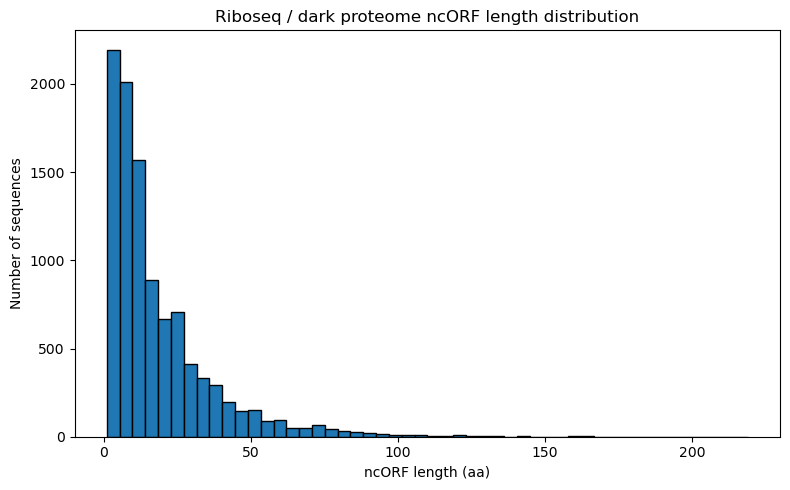

In [23]:
# Plot length distribution for all original Riboseq / dark proteome ncORF sequences
# This shows the full size distribution before cleanup and XTEN padding.

from pathlib import Path
import matplotlib.pyplot as plt

# Use the original processed Riboseq FASTA before cleanup/padding
riboseq_dir = Path("/Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/Riboseq")
input_fasta = riboseq_dir / "darkproteome_riboseq_orfs.primary.fasta"

# Read FASTA records one at a time
def read_fasta(path):
    header, seq = None, []

    with path.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq)

                header, seq = line[1:], []

            elif line:
                seq.append(line)

        if header is not None:
            yield header, "".join(seq)

# Collect all sequence lengths
lengths = []

for header, seq in read_fasta(input_fasta):
    seq = seq.upper().replace("*", "")
    lengths.append(len(seq))

# Print summary stats
print(f"Total ncORF sequences: {len(lengths):,}")

if lengths:
    print(f"Shortest sequence: {min(lengths)} aa")
    print(f"Longest sequence: {max(lengths)} aa")
    print(f"Sequences below 5 aa: {sum(length < 5 for length in lengths):,}")
    print(f"Sequences below 64 aa: {sum(length < 64 for length in lengths):,}")

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=50, edgecolor="black")
plt.xlabel("ncORF length (aa)")
plt.ylabel("Number of sequences")
plt.title("Riboseq / dark proteome ncORF length distribution")
plt.tight_layout()
plt.show()

In [24]:
%%bash

# Dark proteome (from darkprot Riboseq) fragment generation
#
# We split the input before pepsyn/CD-HIT because XTEN-padded short ORFs share artificial
# padding sequence. If padded ORFs are clustered with the same 95% local settings used for
# normal peptides, unrelated short ORFs may collapse because of the common XTEN region.

cd "/Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/Riboseq"

# -----------------------------------------------------------------------------
# 1) Long ORFs: real, unpadded sequences >=64 aa
#    These can use the standard 64-aa / 42-overlap tiling and 95% CD-HIT settings.
# -----------------------------------------------------------------------------

# Generate 64-aa peptides with 42-aa overlap from long unpadded ORFs
cat darkproteome_riboseq_orfs.primary.long_unpadded.fasta \
| pepsyn x2ggsg - - \
| pepsyn tile -l 64 -p 42 - - \
| pepsyn disambiguateaa - - \
> darkproteome_riboseq_orfs.primary.long_unpadded.w64s42.raw.tiles.fasta

# Generate C-terminal peptides separately to prevent C-terminal truncation
cat darkproteome_riboseq_orfs.primary.long_unpadded.fasta \
| pepsyn x2ggsg - - \
| pepsyn ctermpep -l 64 - - \
| pepsyn disambiguateaa - - \
> darkproteome_riboseq_orfs.primary.long_unpadded.w64.cterm.raw.tiles.fasta

# Deduplicate long-ORF regular tiles with the same 95% / A53 settings used for GENCODE
cd-hit -i darkproteome_riboseq_orfs.primary.long_unpadded.w64s42.raw.tiles.fasta \
-o darkproteome_riboseq_orfs.primary.long_unpadded.w64s42.cdhit_c95_A53.tiles.fasta \
-c 0.95 -G 0 -A 53 -M 0 -T 1 -d 0

# Deduplicate long-ORF C-terminal tiles at 95% identity with FULL-LENGTH coverage.
# Following Mohan et al. 2018 / i-PanSeq, C-terminal peptides use full-length alignment
# (-aL 1.0 -aS 1.0) so the ORF's terminal residues (C-terminal epitopes) are not lost.
cd-hit -i darkproteome_riboseq_orfs.primary.long_unpadded.w64.cterm.raw.tiles.fasta \
-o darkproteome_riboseq_orfs.primary.long_unpadded.w64.cterm.cdhit_c95_full_length.tiles.fasta \
-c 0.95 -G 0 -aL 1.0 -aS 1.0 -M 0 -T 1 -d 0

# -----------------------------------------------------------------------------
# 2) Short ORFs: XTEN-padded sequences that are exactly 64 aa
#    These are deduplicated only at 100% full-length identity, so two short ORFs
#    do not collapse merely because they share the same XTEN padding.
# -----------------------------------------------------------------------------

# Each short padded ORF is already exactly 64 aa, so one tile captures the full construct.
# A separate C-terminal pepsyn step is not needed for this padded-only set.
cat darkproteome_riboseq_orfs.primary.short_XTEN_padded.fasta \
| pepsyn x2ggsg - - \
| pepsyn tile -l 64 -p 42 - - \
| pepsyn disambiguateaa - - \
> darkproteome_riboseq_orfs.primary.short_XTEN_padded.w64.raw.tiles.fasta

# Deduplicate padded short ORFs only if the full 64-aa peptide is identical.
cd-hit -i darkproteome_riboseq_orfs.primary.short_XTEN_padded.w64.raw.tiles.fasta \
-o darkproteome_riboseq_orfs.primary.short_XTEN_padded.w64.cdhit_c100_full_length.tiles.fasta \
-c 1.0 -G 1 -aL 1.0 -aS 1.0 -M 0 -T 1 -d 0


tile: 359seq [00:00, 292834.53seq/s]
ctermpep: 359seq [00:00, 54691.09seq/s]


Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 21:58:32
Command: cd-hit -i
         darkproteome_riboseq_orfs.primary.long_unpadded.w64s42.raw.tiles.fasta
         -o
         darkproteome_riboseq_orfs.primary.long_unpadded.w64s42.cdhit_c95_A53.tiles.fasta
         -c 0.95 -G 0 -A 53 -M 0 -T 1 -d 0

Started: Mon Jun 29 15:05:52 2026
                            Output                              
----------------------------------------------------------------
total seq: 566
longest and shortest : 64 and 64
Total letters: 36224
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 0M
Buffer          : 1 X 16M = 16M
Table           : 1 X 65M = 65M
Miscellaneous   : 0M
Total           : 81M

Table limit with the given memory limit:
Max number of representatives: 4000000
Max number of word counting entries: 82032000

comparing sequences from          0  to        566

      566  finished        462  clusters

Approximated maximum memory consumption: 81M
w

tile: 8112seq [00:00, 93958.60seq/s]


Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 21:58:32
Command: cd-hit -i
         darkproteome_riboseq_orfs.primary.short_XTEN_padded.w64.raw.tiles.fasta
         -o
         darkproteome_riboseq_orfs.primary.short_XTEN_padded.w64.cdhit_c100_full_length.tiles.fasta
         -c 1.0 -G 1 -aL 1.0 -aS 1.0 -M 0 -T 1 -d 0

Started: Mon Jun 29 15:05:52 2026
                            Output                              
----------------------------------------------------------------
total seq: 8112
longest and shortest : 64 and 64
Total letters: 519168
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 1M
Buffer          : 1 X 16M = 16M
Table           : 1 X 65M = 65M
Miscellaneous   : 0M
Total           : 83M

Table limit with the given memory limit:
Max number of representatives: 4000000
Max number of word counting entries: 82032000

comparing sequences from          0  to       8112
........
     8112  finished       8097  clusters

Approximated max

In [ ]:
# Record CD-HIT collapsed clusters for the dark-proteome / Riboseq sets
# Mirrors the GENCODE collapse-record cell so Riboseq also gets
# marked_representatives FASTAs (preserving collapsed_n/cluster metadata) that the
# merge cell prefers. If a representative has other peptides collapsed into it, its
# FASTA header is marked with "#", and a TSV records every collapsed member.
#
# Dark-proteome/Riboseq CD-HIT outputs come from three separate sets:
# 1. long unpadded regular 64-aa / 42-overlap tiles, deduplicated at 95%
# 2. long unpadded C-terminal tiles, deduplicated at 95%
# 3. short XTEN-padded 64-aa peptides, deduplicated only at 100% full-length identity

from pathlib import Path
import csv
import re

riboseq_dir = Path("/Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/Riboseq")

cdhit_fastas = [
    riboseq_dir / "darkproteome_riboseq_orfs.primary.long_unpadded.w64s42.cdhit_c95_A53.tiles.fasta",
    riboseq_dir / "darkproteome_riboseq_orfs.primary.long_unpadded.w64.cterm.cdhit_c95_full_length.tiles.fasta",
    riboseq_dir / "darkproteome_riboseq_orfs.primary.short_XTEN_padded.w64.cdhit_c100_full_length.tiles.fasta",
]

# Put all collapse records in one folder
collapse_dir = riboseq_dir / "cdhit_collapse_records"
collapse_dir.mkdir(exist_ok=True)

# Read FASTA records
def read_fasta(path):
    header, seq = None, []

    with path.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq)

                header, seq = line[1:], []

            elif line:
                seq.append(line)

        if header is not None:
            yield header, "".join(seq)

# Parse one CD-HIT .clstr file
def parse_clstr(clstr_file):
    clusters = []
    cluster = None
    header_re = re.compile(r">(.+)\.\.\.")

    with clstr_file.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">Cluster"):
                if cluster is not None:
                    clusters.append(cluster)

                cluster_id = line.replace(">Cluster ", "")
                cluster = {"cluster_id": cluster_id, "members": []}
                continue

            match = header_re.search(line)
            if not match:
                continue

            header = match.group(1)
            is_representative = line.endswith("*")
            identity = "representative" if is_representative else line.split(" at ")[-1]

            cluster["members"].append({
                "header": header,
                "is_representative": is_representative,
                "identity": identity,
                "raw_line": line,
            })

    if cluster is not None:
        clusters.append(cluster)

    return clusters

# Write annotated FASTA and collapse table for one CD-HIT FASTA
def write_collapse_records(cdhit_fasta):
    clstr_file = Path(str(cdhit_fasta) + ".clstr")

    if not cdhit_fasta.exists():
        print(f"Missing FASTA: {cdhit_fasta}")
        return

    if not clstr_file.exists():
        print(f"Missing cluster file: {clstr_file}")
        return

    clusters = parse_clstr(clstr_file)

    # Find representatives whose clusters contain more than one peptide
    collapsed_reps = {}

    for cluster in clusters:
        representative = [m for m in cluster["members"] if m["is_representative"]][0]
        rep_header = representative["header"]

        if len(cluster["members"]) > 1:
            collapsed_reps[rep_header] = cluster

    # Define output files
    stem = cdhit_fasta.name.removesuffix(".fasta")
    annotated_fasta = collapse_dir / f"{stem}.marked_representatives.fasta"
    cluster_tsv = collapse_dir / f"{stem}.cluster_members.tsv"

    # Write annotated FASTA
    # Add "#" only to representatives that have collapsed members
    with annotated_fasta.open("w") as out:
        for header, seq in read_fasta(cdhit_fasta):
            if header in collapsed_reps:
                cluster = collapsed_reps[header]
                collapsed_n = len(cluster["members"]) - 1
                header = f"{header} # collapsed_n={collapsed_n} cluster={cluster['cluster_id']}"

            out.write(f">{header}\n{seq}\n")

    # Write full cluster membership table
    with cluster_tsv.open("w", newline="") as out:
        writer = csv.writer(out, delimiter="\t")
        writer.writerow([
            "cluster_id",
            "representative_header",
            "representative_marked_header",
            "cluster_size",
            "member_role",
            "member_header",
            "identity_to_representative",
            "raw_cdhit_line",
        ])

        for cluster in clusters:
            representative = [m for m in cluster["members"] if m["is_representative"]][0]
            rep_header = representative["header"]

            if len(cluster["members"]) > 1:
                marked_rep_header = f"{rep_header} #"
            else:
                marked_rep_header = rep_header

            for member in cluster["members"]:
                member_role = "representative" if member["is_representative"] else "collapsed"

                writer.writerow([
                    cluster["cluster_id"],
                    rep_header,
                    marked_rep_header,
                    len(cluster["members"]),
                    member_role,
                    member["header"],
                    member["identity"],
                    member["raw_line"],
                ])

    # Print summary
    total_collapsed_members = sum(len(c["members"]) - 1 for c in collapsed_reps.values())

    print(f"\nProcessed: {cdhit_fasta.name}")
    print(f"- Total representative peptides: {len(clusters):,}")
    print(f"- Representatives marked with #: {len(collapsed_reps):,}")
    print(f"- Total collapsed input peptides: {total_collapsed_members:,}")
    print(f"- Annotated FASTA: {annotated_fasta}")
    print(f"- Cluster table:   {cluster_tsv}")

# Run for all three Riboseq sets
for cdhit_fasta in cdhit_fastas:
    write_collapse_records(cdhit_fasta)


In [26]:
# Process GFP negative control
# Input: UniProt GFP P42212 FASTA
# Output: working FASTA copied into a separate NegativeControls construction folder

from pathlib import Path
import shutil

project_dir = Path("/Users/richbaconburger/Desktop/humanpeptidome_JP_library")
negative_control_dir = project_dir / "peptidome_library_construction" / "NegativeControls"
negative_control_dir.mkdir(parents=True, exist_ok=True)

input_fasta = Path("/Users/richbaconburger/Desktop/pluvinagerotation-vzv/positive and negative controls/nc_uniprotkb_GFP_P42212_2026_01_26.fasta")
output_fasta = negative_control_dir / "nc_uniprotkb_GFP_P42212_2026_01_26.fasta"

shutil.copyfile(input_fasta, output_fasta)

# Quick summary so the control is easy to verify
header = None
seq = []
with output_fasta.open() as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            header = line
        else:
            seq.append(line.upper())

seq = "".join(seq)

print("GFP negative control copied:")
print(f"- Input:  {input_fasta}")
print(f"- Output: {output_fasta}")
print(f"- Header: {header}")
print(f"- Length: {len(seq):,} aa")


# --- XTEN linker negative control ---
# A defined 64-aa XTEN linker peptide, added as a SECOND negative control alongside GFP.
# XTEN is a non-human, unstructured sequence with no expected human antibody reactivity,
# so it acts as a clean background / non-binding control at full insert length (64 aa).
# It reuses the same XTEN sequence used for short-protein padding (59 aa), extended
# cyclically to exactly 64 aa. As a single fixed peptide it does not need tiling/CD-HIT.

XTEN = "ATPESSGSETPGTSESATPESSGSEAPGTSTEPSEGSAPGSEPATSGSETPGTSESATP"  # 59 aa
xten_64 = (XTEN * 2)[:64]  # cyclically extend to exactly 64 aa
assert len(xten_64) == 64, f"Expected 64 aa XTEN control, got {len(xten_64)}"

xten_control_fasta = negative_control_dir / "nc_XTEN_linker_64aa.fasta"
with xten_control_fasta.open("w") as f:
    f.write(f">XTEN_linker_64aa\n{xten_64}\n")

print("\nXTEN linker negative control written:")
print(f"- Output:   {xten_control_fasta}")
print(f"- Length:   {len(xten_64)} aa")
print(f"- Sequence: {xten_64}")


GFP negative control copied:
- Input:  /Users/richbaconburger/Desktop/pluvinagerotation-vzv/positive and negative controls/nc_uniprotkb_GFP_P42212_2026_01_26.fasta
- Output: /Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/NegativeControls/nc_uniprotkb_GFP_P42212_2026_01_26.fasta
- Header: >sp|P42212|GFP_AEQVI Green fluorescent protein OS=Aequorea victoria OX=6100 GN=GFP PE=1 SV=1
- Length: 238 aa


In [27]:
%%bash

# GFP negative-control fragment generation
#
# GFP is 238 aa, so it is a naturally long, unpadded control sequence.
# Keep it in its own NegativeControls folder so control peptides remain easy to trace.
# Deduplicate only exact full-length duplicates, because control representation is more
# important than aggressive similarity-based collapse for this small control set.

cd "/Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction/NegativeControls"

# Generate 64-aa peptides with 42-aa overlap from GFP
cat nc_uniprotkb_GFP_P42212_2026_01_26.fasta \
| pepsyn x2ggsg - - \
| pepsyn tile -l 64 -p 42 - - \
| pepsyn disambiguateaa - - \
> nc_uniprotkb_GFP_P42212.w64s42.raw.tiles.fasta

# Generate the GFP C-terminal peptide separately to prevent C-terminal truncation
cat nc_uniprotkb_GFP_P42212_2026_01_26.fasta \
| pepsyn x2ggsg - - \
| pepsyn ctermpep -l 64 - - \
| pepsyn disambiguateaa - - \
> nc_uniprotkb_GFP_P42212.w64.cterm.raw.tiles.fasta

# Deduplicate GFP regular tiles only if the full 64-aa peptide is identical
cd-hit -i nc_uniprotkb_GFP_P42212.w64s42.raw.tiles.fasta \
-o nc_uniprotkb_GFP_P42212.w64s42.cdhit_c100_full_length.tiles.fasta \
-c 1.0 -G 1 -aL 1.0 -aS 1.0 -M 0 -T 1 -d 0

# Deduplicate GFP C-terminal tiles only if the full 64-aa peptide is identical
cd-hit -i nc_uniprotkb_GFP_P42212.w64.cterm.raw.tiles.fasta \
-o nc_uniprotkb_GFP_P42212.w64.cterm.cdhit_c100_full_length.tiles.fasta \
-c 1.0 -G 1 -aL 1.0 -aS 1.0 -M 0 -T 1 -d 0


tile: 1seq [00:00, 133.08seq/s]
ctermpep: 1seq [00:00, 113.08seq/s]


Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 21:58:32
Command: cd-hit -i
         nc_uniprotkb_GFP_P42212.w64s42.raw.tiles.fasta -o
         nc_uniprotkb_GFP_P42212.w64s42.cdhit_c100_full_length.tiles.fasta
         -c 1.0 -G 1 -aL 1.0 -aS 1.0 -M 0 -T 1 -d 0

Started: Mon Jun 29 15:05:53 2026
                            Output                              
----------------------------------------------------------------
total seq: 8
longest and shortest : 64 and 64
Total letters: 512
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 0M
Buffer          : 1 X 16M = 16M
Table           : 1 X 65M = 65M
Miscellaneous   : 0M
Total           : 81M

Table limit with the given memory limit:
Max number of representatives: 4000000
Max number of word counting entries: 82032000

comparing sequences from          0  to          8

        8  finished          8  clusters

Approximated maximum memory consumption: 81M
writing new database
writing clustering info

In [ ]:
# Merge deduplicated peptide sets
#
# This creates one amino-acid FASTA containing all final peptide representatives:
# - GENCODE long unpadded regular tiles
# - GENCODE long unpadded C-terminal tiles
# - GENCODE short XTEN-padded peptides
# - Riboseq/dark-proteome long unpadded regular tiles
# - Riboseq/dark-proteome long unpadded C-terminal tiles
# - Riboseq/dark-proteome short XTEN-padded peptides
# - GFP negative-control regular tiles
# - GFP negative-control C-terminal tiles
# - XTEN linker negative control (single 64-aa peptide)
#
# For GENCODE/Riboseq, prefer marked_representatives FASTA files when present
# because they preserve CD-HIT collapsed-cluster metadata.
# If those are not present, fall back to the plain CD-HIT representative FASTAs.
#
# Each record is given a compact, WHITESPACE-FREE unique ID of the form:
#     <source>|<protein_name>|<specific_id>|<tile>|<fragment_label>
# This matters because the downstream pepsyn encoding pipeline truncates FASTA
# headers at the first whitespace. By putting a unique, space-free ID first and
# leaving the original cluster metadata after a space, the encoded oligos keep a
# real per-peptide identifier while the peptide FASTA stays human-readable.

from pathlib import Path
from collections import Counter

project_dir = Path("/Users/richbaconburger/Desktop/humanpeptidome_JP_library")
construction_dir = project_dir / "peptidome_library_construction"

gencode_dir = construction_dir / "GENCODE"
riboseq_dir = construction_dir / "Riboseq"
negative_control_dir = construction_dir / "NegativeControls"

output_fasta = construction_dir / "human_peptidome_JP_library.merged_peptides.fasta"

# Regular tiles are generated with `pepsyn tile -l 64 -p 42`, so consecutive tiles
# step by (length - overlap) = 22 aa. This drives the fragment_N numbering below.
TILE_STEP = 64 - 42


def read_fasta(path):
    """Yield FASTA records as (header_without_>, sequence)."""
    header, seq = None, []

    with path.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq)

                header, seq = line[1:], []

            elif line:
                seq.append(line)

        if header is not None:
            yield header, "".join(seq)


def choose_fasta(source_dir, fasta_name):
    """
    Use the marked representative FASTA if cluster-generation has been run.
    Otherwise, use the original CD-HIT representative FASTA.
    """
    marked_fasta = source_dir / "cdhit_collapse_records" / fasta_name.replace(
        ".fasta",
        ".marked_representatives.fasta",
    )
    cdhit_fasta = source_dir / fasta_name

    if marked_fasta.exists():
        return marked_fasta, "marked_representatives"

    if cdhit_fasta.exists():
        return cdhit_fasta, "cdhit_representatives"

    raise FileNotFoundError(
        f"Missing both expected FASTA files:\n"
        f"- {marked_fasta}\n"
        f"- {cdhit_fasta}"
    )


def build_unique_id(kind, source_label, core):
    """
    Build a whitespace-free unique ID.

    kind is one of: "gencode", "riboseq", "gfp", "xten".
    core is the header up to (but not including) any ' # ...' cluster metadata.
    Format: <source_label>|<protein>|<specific_id>|<tile>|<fragment_label>

    <fragment_label> reflects the ORIGINAL tile order before CD-HIT collapse:
    regular tiles step by (64 - 42) = 22 aa, so the index is start // 22
    (collapsed tiles simply leave gaps in the numbering). The separately
    generated C-terminal peptide is labeled "C-term".

    Header shapes are validated so a malformed/changed header fails loudly
    instead of silently producing a plausible-but-wrong ID.
    """
    fields = core.split("|")

    if kind == "gencode":
        # ENSP|ENST|ENSG|OTTHUMG|OTTHUMT|transcript|gene|aa|tile  (9 fields)
        if len(fields) < 8:
            raise ValueError(f"Unexpected GENCODE header ({len(fields)} fields): {core!r}")
        specific_id = fields[0]
        protein = fields[-3]
        tile = fields[-1]

    elif kind == "riboseq":
        # orfid:gene:type|tile
        if len(fields) < 2:
            raise ValueError(f"Unexpected Riboseq header ({len(fields)} fields): {core!r}")
        orf_parts = fields[0].split(":")
        if len(orf_parts) < 2:
            raise ValueError(f"Unexpected Riboseq ORF id (need orfid:gene[:type]): {fields[0]!r}")
        specific_id = orf_parts[0]
        protein = orf_parts[1] or "NA"
        tile = fields[-1]

    elif kind == "xten":
        # XTEN_linker_64aa  (single fixed control peptide, no '|' fields)
        specific_id = fields[0]
        protein = "XTEN"
        tile = "0-64"

    elif kind == "gfp":
        # sp|P42212|GFP_AEQVI|tile
        if len(fields) < 4:
            raise ValueError(f"Unexpected GFP header ({len(fields)} fields): {core!r}")
        specific_id = fields[1]
        protein = fields[2]
        tile = fields[-1]

    else:
        raise ValueError(f"Unknown source kind: {kind}")

    # Fragment label reflecting the ORIGINAL tile order (pre CD-HIT collapse).
    # Regular tiles step by (64 - 42) = 22 aa, so fragment index = start // 22;
    # the separately-generated C-terminal peptide is labeled "C-term".
    # Fail loudly on any unexpected tile coordinate so a malformed/changed header
    # can never be silently mislabeled (e.g. floored to the wrong fragment).
    if tile == "CTERM":
        fragment_label = "C-term"
    else:
        try:
            start_s, end_s = tile.split("-", 1)
            tile_start, tile_end = int(start_s), int(end_s)
        except ValueError:
            raise ValueError(f"Unexpected tile coordinate {tile!r} in header: {core!r}")
        if tile_start % TILE_STEP != 0:
            raise ValueError(
                f"Tile start {tile_start} is not a multiple of TILE_STEP={TILE_STEP}: {core!r}"
            )
        fragment_label = f"fragment_{tile_start // TILE_STEP}"

    unique_id = f"{source_label}|{protein}|{specific_id}|{tile}|{fragment_label}"

    # pepsyn keeps only the first whitespace-free token, so the ID must have no spaces.
    if any(ch.isspace() for ch in unique_id):
        raise ValueError(
            f"Unique ID contains whitespace: {unique_id!r} "
            f"(source={source_label}, core={core!r})"
        )

    return unique_id


# All peptide sets to merge: (source_label, kind, folder, cdhit_fasta_filename).
# choose_fasta() prefers each set's marked_representatives FASTA (which carries
# collapsed-cluster metadata) and falls back to the plain CD-HIT FASTA. GFP controls
# have no marked file, so they naturally fall back to their CD-HIT FASTA.
merge_sets = [
    ("GENCODE_long_w64s42",        "gencode", gencode_dir,          "gencode.v50.protein_coding.long_unpadded.w64s42.cdhit_c95_A53.tiles.fasta"),
    ("GENCODE_long_CTERM",         "gencode", gencode_dir,          "gencode.v50.protein_coding.long_unpadded.w64.cterm.cdhit_c95_full_length.tiles.fasta"),
    ("GENCODE_short_XTEN_padded",  "gencode", gencode_dir,          "gencode.v50.protein_coding.short_XTEN_padded.w64.cdhit_c100_full_length.tiles.fasta"),
    ("Riboseq_long_w64s42",        "riboseq", riboseq_dir,          "darkproteome_riboseq_orfs.primary.long_unpadded.w64s42.cdhit_c95_A53.tiles.fasta"),
    ("Riboseq_long_CTERM",         "riboseq", riboseq_dir,          "darkproteome_riboseq_orfs.primary.long_unpadded.w64.cterm.cdhit_c95_full_length.tiles.fasta"),
    ("Riboseq_short_XTEN_padded",  "riboseq", riboseq_dir,          "darkproteome_riboseq_orfs.primary.short_XTEN_padded.w64.cdhit_c100_full_length.tiles.fasta"),
    ("NegativeControl_GFP_w64s42", "gfp",     negative_control_dir, "nc_uniprotkb_GFP_P42212.w64s42.cdhit_c100_full_length.tiles.fasta"),
    ("NegativeControl_GFP_CTERM",  "gfp",     negative_control_dir, "nc_uniprotkb_GFP_P42212.w64.cterm.cdhit_c100_full_length.tiles.fasta"),
    ("NegativeControl_XTEN_64aa",  "xten",    negative_control_dir, "nc_XTEN_linker_64aa.fasta"),
]

# Resolve each set to a concrete FASTA (raises if a set's file is missing)
merge_inputs = [
    (source_label, kind, *choose_fasta(folder, fasta_name))
    for source_label, kind, folder, fasta_name in merge_sets
]


# Merge records
source_counts = Counter()
length_counts = Counter()
sequence_counts = Counter()
id_counts = Counter()

# Build all records in memory first so duplicate IDs can be caught BEFORE any
# file is written (a half-written, invalid merged FASTA must never reach the
# downstream sticky-exclusion / encoding cells).
out_records = []
for source_label, kind, fasta_path, file_type in merge_inputs:
    for header, seq in read_fasta(fasta_path):
        seq = seq.upper().replace("*", "")

        # Separate the sequence core from any ' # collapsed_n=.. cluster=..' metadata
        core, _, meta = header.partition(" # ")

        unique_id = build_unique_id(kind, source_label, core)

        source_counts[source_label] += 1
        length_counts[len(seq)] += 1
        sequence_counts[seq] += 1
        id_counts[unique_id] += 1

        # Whitespace-free unique ID first (pepsyn keeps only this token),
        # original cluster metadata preserved after a space for reference.
        meta_suffix = f" {meta}" if meta else ""
        out_records.append((unique_id, meta_suffix, seq))


# Print summary
print(f"Merged peptide FASTA: {output_fasta}")
print(f"Total peptide records: {sum(source_counts.values()):,}")
print(f"Unique peptide sequences: {len(sequence_counts):,}")
print(f"Unique IDs: {len(id_counts):,}")

# Verify IDs are actually unique (critical for read-to-peptide mapping).
# Fail loudly rather than write a merged FASTA that cannot be mapped back to peptides.
duplicate_ids = {i: n for i, n in id_counts.items() if n > 1}
if duplicate_ids:
    examples = "\n".join(f"- {i}: {n} times" for i, n in list(duplicate_ids.items())[:5])
    raise ValueError(
        f"{len(duplicate_ids):,} record IDs are not unique. "
        f"Unique IDs are required for read-to-peptide mapping.\n{examples}"
    )
print("All record IDs are unique \u2713")

# Only now, after validation passed, write the merged FASTA to disk.
with output_fasta.open("w") as out:
    for unique_id, meta_suffix, seq in out_records:
        out.write(f">{unique_id}{meta_suffix}\n{seq}\n")

print("\nInputs used:")
for source_label, kind, fasta_path, file_type in merge_inputs:
    print(f"- {source_label}: {fasta_path.name} ({file_type})")

print("\nRecords by source:")
for source_label, count in source_counts.items():
    print(f"- {source_label}: {count:,}")

print("\nPeptide lengths:")
for length, count in sorted(length_counts.items()):
    print(f"- {length} aa: {count:,}")

duplicate_sequences = sum(1 for count in sequence_counts.values() if count > 1)
duplicate_records = sum(count - 1 for count in sequence_counts.values() if count > 1)

print("\nDuplicate sequence check across merged FASTA:")
print(f"- Sequences appearing more than once: {duplicate_sequences:,}")
print(f"- Extra duplicate records: {duplicate_records:,}")

if duplicate_sequences:
    print(
        "\nNote: duplicate sequences are reported but not removed. "
        "This preserves source labels and keeps GFP/control peptides traceable."
    )


In [ ]:
# Exclude known "sticky" PhIP-seq peptides (DeRisi-lab Excel sheet of sticky hits)
#
# Some peptides are promiscuous / "sticky" binders in PhIP-seq: they enrich
# nonspecifically regardless of the sample and create background. We remove known
# sticky hits from the merged library BEFORE oligo encoding so they never reach the chip.
#
# Source of the sticky list: the DeRisi-lab "usual suspects" sticky PhIP-seq hits
# (usualsuspects_k10_peptidome.csv). We currently exclude ONLY MYO16A. Its top two
# sticky hits (by antigen-sample hits) are two overlapping MYO16A fragments; per the
# design we exclude any library peptide that CONTAINS the overlapping region shared
# by those two fragments.
#
# Controls (GFP, XTEN) are NOT exempt - they are filtered like every other source.
#
# Inputs:
# - human_peptidome_JP_library.merged_peptides.fasta
# Outputs:
# - human_peptidome_JP_library.filtered_peptides.fasta  (sticky peptides removed; feeds Cell 14 encoding)
# - excluded_sticky_peptides.tsv                         (audit trail of everything dropped)

from pathlib import Path
from collections import Counter

project_dir = Path("/Users/richbaconburger/Desktop/humanpeptidome_JP_library")
construction_dir = project_dir / "peptidome_library_construction"

merged_fasta = construction_dir / "human_peptidome_JP_library.merged_peptides.fasta"
filtered_fasta = construction_dir / "human_peptidome_JP_library.filtered_peptides.fasta"
audit_tsv = construction_dir / "excluded_sticky_peptides.tsv"


# Sticky PhIP-seq hits from the DeRisi-lab Excel sheet.
# Each protein lists the sticky fragment sequences reported in the sheet, in order.
# Add more proteins/fragments here as they are pulled from the sheet.
sticky_hits = {
    "MYO16A": [
        "LEVRNMQEEGSKRTDDKSGPRHFHPSSMSVCAAVDGLGQCLVGPSIWS",  # fragment_52 (2748 ag / 76 healthy hits)
        "PSSMSVCAAVDGLGQCLVGPSIWSPSLHSVFSMDDSSSLPSPRKQPPP",  # fragment_53 (1874 ag / 34 healthy hits)
    ],
}


def longest_overlap(a, b):
    """Longest suffix of a that is also a prefix of b (their overlapping region)."""
    for k in range(min(len(a), len(b)), 0, -1):
        if a[-k:] == b[:k]:
            return a[-k:]
    return ""


# Build the exclusion motifs: the overlapping region between each protein's
# consecutive sticky fragments. Computing the overlap (rather than hard-typing a
# motif) keeps the rule transparent and documented.
exclusion_motifs = {}  # motif -> (protein, "fragment_i n fragment_j")
for protein, frags in sticky_hits.items():
    if len(frags) < 2:
        raise ValueError(
            f"{protein}: need >=2 fragments to compute an overlap motif "
            f"(got {len(frags)})."
        )
    for i in range(len(frags) - 1):
        motif = longest_overlap(frags[i].upper(), frags[i + 1].upper())
        if not motif:
            raise ValueError(f"No overlap between {protein} fragment_{i} and fragment_{i + 1}")
        exclusion_motifs[motif] = (protein, "common sticky motif")

print("Sticky exclusion motifs (DeRisi-lab sticky PhIP-seq hits):")
for motif, (protein, frags) in exclusion_motifs.items():
    print(f"- {protein} ({frags}): {motif}  [{len(motif)} aa]")


def read_fasta(path):
    """Yield FASTA records as (header_without_>, sequence)."""
    header, seq = None, []

    with path.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq)

                header, seq = line[1:], []

            elif line:
                seq.append(line)

        if header is not None:
            yield header, "".join(seq)


# Filter: drop any peptide that contains a sticky motif (substring match), then
# write the surviving peptides and an audit of everything removed.
kept = 0
excluded = []
kept_by_source = Counter()
excluded_by_source = Counter()

with filtered_fasta.open("w") as out:
    for header, seq in read_fasta(merged_fasta):
        upper = seq.upper()
        peptide_id = header.split()[0]
        source = peptide_id.split("|")[0]

        match = None
        for motif, (protein, frags) in exclusion_motifs.items():
            if motif in upper:
                match = (motif, protein, frags)
                break

        if match:
            motif, protein, frags = match
            excluded.append((peptide_id, source, protein, frags, motif, seq))
            excluded_by_source[source] += 1
        else:
            out.write(f">{header}\n{seq}\n")
            kept += 1
            kept_by_source[source] += 1

# Audit trail of everything dropped
with audit_tsv.open("w") as t:
    t.write("dropped_peptide_id\tsource\tsticky_protein\tmatched_fragments\tmotif\tsequence\n")
    for peptide_id, source, protein, frags, motif, seq in excluded:
        t.write(f"{peptide_id}\t{source}\t{protein}\t{frags}\t{motif}\t{seq}\n")

# Summary
total = kept + len(excluded)
print(f"\nMerged peptides:   {total:,}")
print(f"Kept (filtered):   {kept:,}")
print(f"Excluded (sticky): {len(excluded):,}")
print(f"\nFiltered FASTA: {filtered_fasta}")
print(f"Audit TSV:      {audit_tsv}")

if excluded:
    print("\nExcluded by source:")
    for source, n in excluded_by_source.items():
        print(f"- {source}: {n:,}")
    print(f"\nExcluded peptides ({len(excluded)}) - ID and full sequence:")
    for peptide_id, source, protein, frags, motif, seq in excluded:
        print(f"\n  ID:       {peptide_id}")
        print(f"  matched:  {protein} {frags}  (motif {motif})")
        print(f"  sequence: {seq}")
else:
    print("\nNo peptides matched the sticky motifs.")


In [31]:
%%bash

# Convert the filtered (sticky-excluded) amino-acid peptide library into DNA oligos for cloning
#
# Input:
# - human_peptidome_JP_library.filtered_peptides.fasta  (sticky peptides already removed)
#
# Output:
# - human_peptidome_JP_library.raw_encoded_oligos.fasta  (pre-repair pepsyn output)
#
# Pipeline:
# 1. stripstop      - Remove stop codons (*) from peptides
# 2. pad -l 64      - Ensure all peptide inserts are 64 aa before reverse translation
# 3. disambiguateaa - Replace ambiguous aa (B,J,Z,X) with standard amino acids
# 4. revtrans       - Reverse translate to DNA; exclude rare E. coli codons below 1% frequency
# 5. prefix         - Add 5' cloning adapter (19 bp)
# 6. suffix         - Add 3' sequence: FLAG tag (24 bp) + cloning adapter (19 bp) = 43 bp total
# 7. recodesite     - Remove EcoRI/HindIII/XhoI sites from coding region only
#                     by protecting the 19-bp left adapter and 43-bp right suffix

set -euo pipefail

cd "/Users/richbaconburger/Desktop/humanpeptidome_JP_library/peptidome_library_construction"

FILTERED_PEPTIDES="human_peptidome_JP_library.filtered_peptides.fasta"
OUTPUT_OLIGOS="human_peptidome_JP_library.raw_encoded_oligos.fasta"

if [ ! -f "$FILTERED_PEPTIDES" ]; then
    echo "Missing filtered peptide FASTA: $FILTERED_PEPTIDES"
    echo "Run the merge and sticky-exclusion cells before this nucleotide-production cell."
    exit 1
fi

cat "$FILTERED_PEPTIDES" \
| pepsyn stripstop - - \
| pepsyn pad -l 64 - - \
| pepsyn disambiguateaa - - \
| pepsyn revtrans --codon-freq-threshold 0.01 - - \
| pepsyn prefix -p CCTATACTTCCAAGGCGCA - - \
| pepsyn suffix -s GACTACAAAGATGACGACGATAAAGGTGACTCTCTGTCTTGGC - - \
| pepsyn recodesite --site EcoRI --site HindIII --site XhoI --clip-left 19 --clip-right 43 - - \
> "$OUTPUT_OLIGOS"

echo "Encoded oligo FASTA written: $OUTPUT_OLIGOS"


revtrans: 726121seq [06:05, 1986.85seq/s]


Encoded oligo FASTA written: human_peptidome_JP_library.encoded_oligos.fasta


In [ ]:
# Option B GC / homopolymer repair (DNAChisel)
#
# pepsyn already produced E. coli codon-optimized oligos. A small minority fall
# outside the synthesis-friendly window (high/low GC or long homopolymer runs).
# This cell re-encodes ONLY those flagged oligos. It reads the raw pepsyn output
# and writes a separate, post-repair FASTA, so the raw oligos are preserved and the
# downstream GC/QC cells see the final, submission-ready library.
#
# Design intent (preserve E. coli expression, minimal disruption):
# - GC is a hard CONSTRAINT (35-65% band), never a minimize objective, so codons
#   are nudged only enough to enter the band rather than pushed AT-rich.
# - The codon OBJECTIVE matches E. coli usage, keeping changed codons natural.
# - 5' adapter (19 bp) and 3' FLAG+adapter (43 bp) are locked; translation is
#   enforced over the 192 bp coding region; the same EcoRI/HindIII/XhoI sites are
#   excluded. Only flagged oligos are touched; everything else passes through.

import random
from pathlib import Path

import numpy as np
from dnachisel import (
    DnaOptimizationProblem, EnforceTranslation, AvoidChanges,
    EnforceGCContent, AvoidPattern, CodonOptimize, EnzymeSitePattern,
)

random.seed(0)
np.random.seed(0)

raw_file = Path(
    "/Users/richbaconburger/Desktop/humanpeptidome_JP_library/"
    "peptidome_library_construction/"
    "human_peptidome_JP_library.raw_encoded_oligos.fasta"
)
final_file = Path(
    "/Users/richbaconburger/Desktop/humanpeptidome_JP_library/"
    "peptidome_library_construction/"
    "human_peptidome_JP_library.encoded_oligos.fasta"
)

# Repair spec
EXPECTED_LEN = 254
CODING = (19, 211)                  # 192 bp coding region (locked adapters either side)
GC_MIN, GC_MAX = 0.35, 0.65        # global GC band (hard constraint)
HOMOPOLYMER_MAX = 9                # flag/forbid any run >= 10
SITES = ["EcoRI", "HindIII", "XhoI"]


def read_fasta(path):
    """Yield FASTA records as (header_without_>, sequence)."""
    header, seq = None, []

    with path.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq)

                header, seq = line[1:], []

            elif line:
                seq.append(line)

        if header is not None:
            yield header, "".join(seq)


def gc_frac(seq):
    seq = seq.upper()
    return (seq.count("G") + seq.count("C")) / len(seq) if seq else 0


def max_homopolymer(seq):
    """Length of the longest single-base run."""
    best = run = 0
    prev = ""
    for b in seq.upper():
        run = run + 1 if b == prev else 1
        prev = b
        best = max(best, run)
    return best


def has_site(seq):
    sites = {"EcoRI": "GAATTC", "HindIII": "AAGCTT", "XhoI": "CTCGAG"}
    s = seq.upper()
    return any(site in s for site in sites.values())


def is_flagged(seq):
    return (
        len(seq) == EXPECTED_LEN and (
            not (GC_MIN <= gc_frac(seq) <= GC_MAX)
            or max_homopolymer(seq) > HOMOPOLYMER_MAX
            or has_site(seq)
        )
    )


def repair(seq):
    """Re-encode a flagged oligo into the GC band with no long homopolymers / sites."""
    n = len(seq)
    constraints = [
        EnforceTranslation(location=CODING),
        AvoidChanges(location=(0, CODING[0])),    # lock 5' adapter
        AvoidChanges(location=(CODING[1], n)),    # lock FLAG + 3' adapter
        EnforceGCContent(mini=GC_MIN, maxi=GC_MAX),
    ]
    constraints += [AvoidPattern(b * (HOMOPOLYMER_MAX + 1)) for b in "ATGC"]
    constraints += [AvoidPattern(EnzymeSitePattern(s)) for s in SITES]

    problem = DnaOptimizationProblem(
        sequence=seq,
        constraints=constraints,
        objectives=[CodonOptimize(species="e_coli",
                                  method="match_codon_usage",
                                  location=CODING)],
        logger=None,
    )
    problem.resolve_constraints()
    problem.optimize()
    return problem.sequence


# Repair flagged oligos, pass the rest through unchanged
records = list(read_fasta(raw_file))
flagged_before = [i for i, (_, s) in enumerate(records) if is_flagged(s)]
print(f"Total oligos: {len(records):,}")
print(f"Flagged for repair: {len(flagged_before):,}")

flagged_set = set(flagged_before)
repaired = []
for i, (header, seq) in enumerate(records):
    if i in flagged_set:
        seq = repair(seq)
    repaired.append((header, seq))
    if (i + 1) % 100000 == 0:
        print(f"  processed {i + 1:,} / {len(records):,}")

# Report how many flagged oligos could not be brought within the parameters.
# We still write the full library; these residual cases are surfaced here and by QC.
still_flagged = [i for i in flagged_before if is_flagged(repaired[i][1])]
print(f"Still outside parameters after repair: {len(still_flagged):,}"
      + (" ✓" if not still_flagged else f" ✗ examples: {[records[i][0] for i in still_flagged[:3]]}"))

with final_file.open("w") as out:
    for header, seq in repaired:
        out.write(f">{header}\n{seq}\n")

print(f"Wrote {len(repaired):,} oligos to {final_file.name}")


Total sequences: 726,121
Mean GC%: 49.38
Min GC%: 35.04
Max GC%: 64.96


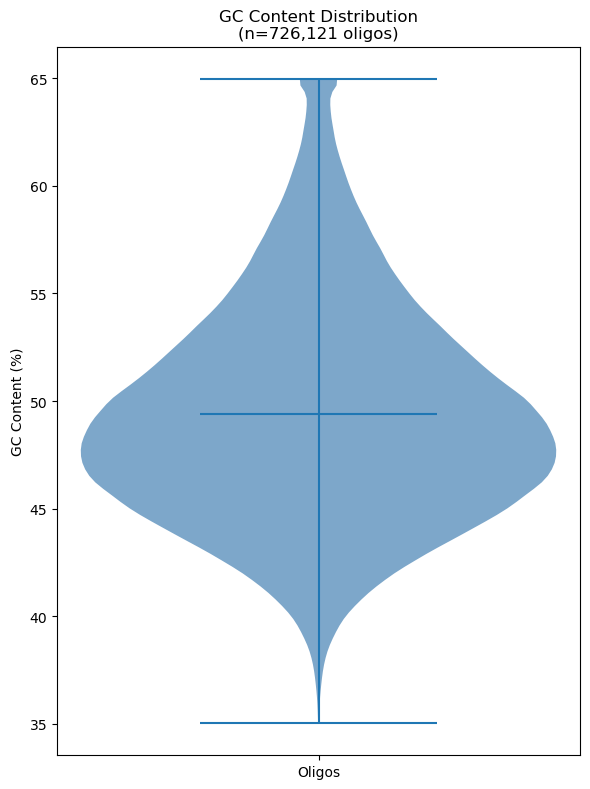

In [60]:
# GC content analysis of encoded oligo sequences

from pathlib import Path
import matplotlib.pyplot as plt


def read_fasta(path):
    """Yield FASTA records as (header_without_>, sequence)."""
    header, seq = None, []

    with path.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq)

                header, seq = line[1:], []

            elif line:
                seq.append(line)

        if header is not None:
            yield header, "".join(seq)


def calc_gc(seq):
    """GC percentage of a DNA sequence."""
    seq = seq.upper()
    return 100 * (seq.count("G") + seq.count("C")) / len(seq) if seq else 0


# Encoded oligo FASTA from the nucleotide-production cell
oligo_file = Path(
    "/Users/richbaconburger/Desktop/humanpeptidome_JP_library/"
    "peptidome_library_construction/"
    "human_peptidome_JP_library.encoded_oligos.fasta"
)

gc_values = [calc_gc(seq) for _, seq in read_fasta(oligo_file)]

# Print summary stats
print(f"Total sequences: {len(gc_values):,}")
print(f"Mean GC%: {sum(gc_values) / len(gc_values):.2f}")
print(f"Min GC%: {min(gc_values):.2f}")
print(f"Max GC%: {max(gc_values):.2f}")

# Violin plot
fig, ax = plt.subplots(figsize=(6, 8))
parts = ax.violinplot(gc_values, positions=[1], showmeans=True)
parts["bodies"][0].set_facecolor("steelblue")
parts["bodies"][0].set_alpha(0.7)

ax.set_ylabel("GC Content (%)")
ax.set_title(f"GC Content Distribution\n(n={len(gc_values):,} oligos)")
ax.set_xticks([1])
ax.set_xticklabels(["Oligos"])

plt.tight_layout()
plt.show()


Source                       n    mean     max      >65%      >70%
GENCODE peptidome      717,270   49.3%   65.0%         0         0
Riboseq ncORFs           8,842   57.6%   65.0%         0         0
GFP control                  9   44.4%   48.0%         0         0


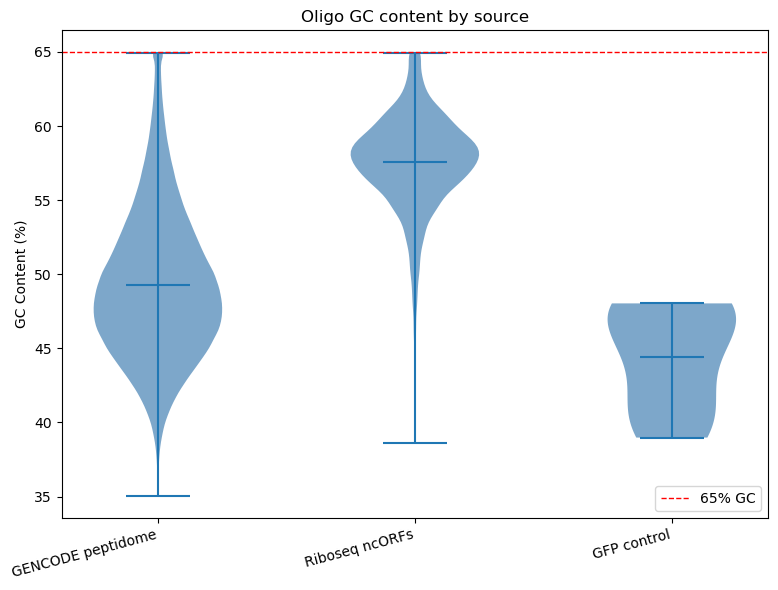

In [63]:
# GC content by source: peptidome (GENCODE) vs ncORFs (Riboseq) vs negative controls (GFP + XTEN)
#
# Splits the encoded oligos by their source label (the part of the unique ID before
# the first "|") so we can see whether one source drives the high-GC tail. Useful
# for deciding whether/where to lower GC.

from pathlib import Path
import matplotlib.pyplot as plt


def read_fasta(path):
    """Yield FASTA records as (header_without_>, sequence)."""
    header, seq = None, []

    with path.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq)

                header, seq = line[1:], []

            elif line:
                seq.append(line)

        if header is not None:
            yield header, "".join(seq)


def calc_gc(seq):
    """GC percentage of a DNA sequence."""
    seq = seq.upper()
    return 100 * (seq.count("G") + seq.count("C")) / len(seq) if seq else 0


def classify(header):
    """Map an oligo header to a broad source category."""
    label = header.split("|")[0]
    if label.startswith("GENCODE"):
        return "GENCODE peptidome"
    if label.startswith("Riboseq"):
        return "Riboseq ncORFs"
    if label.startswith("NegativeControl"):
        return "Negative controls"
    return "other"


oligo_file = Path(
    "/Users/richbaconburger/Desktop/humanpeptidome_JP_library/"
    "peptidome_library_construction/"
    "human_peptidome_JP_library.encoded_oligos.fasta"
)

# Collect GC% per source category
gc_by_source = {}
for header, seq in read_fasta(oligo_file):
    gc_by_source.setdefault(classify(header), []).append(calc_gc(seq))

# Fixed plot order (skip categories with no records)
order = ["GENCODE peptidome", "Riboseq ncORFs", "Negative controls", "other"]
categories = [c for c in order if gc_by_source.get(c)]

# Per-source summary
print(f"{'Source':<20}{'n':>10}{'mean':>8}{'max':>8}{'>65%':>10}{'>70%':>10}")
for c in categories:
    vals = gc_by_source[c]
    n = len(vals)
    over65 = sum(v > 65 for v in vals)
    over70 = sum(v > 70 for v in vals)
    print(
        f"{c:<20}{n:>10,}{sum(vals)/n:>7.1f}%{max(vals):>7.1f}%"
        f"{over65:>10,}{over70:>10,}"
    )

# Grouped violin plot
fig, ax = plt.subplots(figsize=(8, 6))
data = [gc_by_source[c] for c in categories]
parts = ax.violinplot(data, positions=range(1, len(categories) + 1), showmeans=True)
for body in parts["bodies"]:
    body.set_facecolor("steelblue")
    body.set_alpha(0.7)

ax.axhline(65, color="red", linestyle="--", linewidth=1, label="65% GC")
ax.set_ylabel("GC Content (%)")
ax.set_title("Oligo GC content by source")
ax.set_xticks(range(1, len(categories) + 1))
ax.set_xticklabels(categories, rotation=15, ha="right")
ax.legend()

plt.tight_layout()
plt.show()


In [59]:
# QC: Check encoded oligos for ID uniqueness, stop codons, restriction sites, and length

from pathlib import Path

STOP_CODONS = {"TAA", "TAG", "TGA"}
SITES = {"EcoRI": "GAATTC", "HindIII": "AAGCTT", "XhoI": "CTCGAG"}

# Expected oligo structure: 19 bp 5' adapter + 192 bp coding (64 aa x 3)
# + 24 bp FLAG + 19 bp 3' adapter = 254 bp
EXPECTED_LEN = 254
LEFT_ADAPTER_LEN = 19
RIGHT_SUFFIX_LEN = 43  # 24 bp FLAG + 19 bp 3' adapter

# Fixed flanking sequences added by the encode cell (pepsyn prefix/suffix).
# These must survive encoding and the DNAChisel repair untouched.
LEFT_ADAPTER = "CCTATACTTCCAAGGCGCA"
RIGHT_SUFFIX = "GACTACAAAGATGACGACGATAAAGGTGACTCTCTGTCTTGGC"

# Repair targets enforced by the DNAChisel cell (Cell 15)
GC_MIN, GC_MAX = 0.35, 0.65
HOMOPOLYMER_MAX = 9

oligo_file = Path(
    "/Users/richbaconburger/Desktop/humanpeptidome_JP_library/"
    "peptidome_library_construction/"
    "human_peptidome_JP_library.encoded_oligos.fasta"
)


def read_fasta(path):
    """Yield FASTA records as (header_without_>, sequence)."""
    header, seq = None, []

    with path.open() as f:
        for line in f:
            line = line.strip()

            if line.startswith(">"):
                if header is not None:
                    yield header, "".join(seq)

                header, seq = line[1:], []

            elif line:
                seq.append(line)

        if header is not None:
            yield header, "".join(seq)


def gc_frac(seq):
    """GC fraction of a DNA sequence."""
    return (seq.count("G") + seq.count("C")) / len(seq) if seq else 0


def max_homopolymer(seq):
    """Length of the longest single-base run."""
    best = run = 0
    prev = ""
    for b in seq:
        run = run + 1 if b == prev else 1
        prev = b
        best = max(best, run)
    return best


# pepsyn keeps only the first whitespace-free token as the oligo ID.
# Records is a list (not a dict) because those IDs may repeat across a stale file.
records = [(header.split()[0], seq.upper()) for header, seq in read_fasta(oligo_file)]

# 1) ID uniqueness: the read-to-peptide mapping contract. Colliding IDs (e.g. from a
#    stale encoded_oligos.fasta) mean reads cannot be assigned to a source peptide.
ids = [h for h, _ in records]
duplicate_id_count = len(ids) - len(set(ids))

# 2) Stop codons in the coding region only (skip the 19 bp 5' adapter and 43 bp suffix)
coding_start = LEFT_ADAPTER_LEN
coding_end = EXPECTED_LEN - RIGHT_SUFFIX_LEN
stops = []
for h, seq in records:
    coding = seq[coding_start:coding_end]
    for i in range(0, len(coding) - 2, 3):
        if coding[i:i + 3] in STOP_CODONS:
            stops.append((h, i, coding[i:i + 3]))

# 3) Restriction sites anywhere in the full oligo (all occurrences, not just the first)
sites = []
for h, seq in records:
    for name, site in SITES.items():
        start = seq.find(site)
        while start != -1:
            sites.append((h, name, start))
            start = seq.find(site, start + 1)

# 4) Length
lengths = {len(seq) for _, seq in records}
wrong_len = [(h, len(seq)) for h, seq in records if len(seq) != EXPECTED_LEN]

# 5) Flanking sequences untouched: the output 5' adapter and 3' suffix must EXACTLY
#    equal the sequences fed in by the encode cell (pepsyn prefix/suffix). Encoding
#    and the DNAChisel repair (which locks the adapters) must not alter them. Checked
#    separately for the 5' and 3' flanks so any drift is unambiguous.
bad_left = [(h, seq[:LEFT_ADAPTER_LEN]) for h, seq in records
            if seq[:LEFT_ADAPTER_LEN] != LEFT_ADAPTER]
bad_right = [(h, seq[-RIGHT_SUFFIX_LEN:]) for h, seq in records
             if seq[-RIGHT_SUFFIX_LEN:] != RIGHT_SUFFIX]
bad_flank = bad_left + bad_right

# 6) GC band: every oligo must sit within 35-65% (the DNAChisel repair target)
bad_gc = [(h, round(100 * gc_frac(seq), 1)) for h, seq in records
          if not (GC_MIN <= gc_frac(seq) <= GC_MAX)]

# 7) Homopolymer: no single-base run >= 10
bad_homopolymer = [(h, max_homopolymer(seq)) for h, seq in records
                   if max_homopolymer(seq) > HOMOPOLYMER_MAX]

# 8) Record count matches the filtered peptide library (no oligos lost or added
#    during encoding + DNAChisel repair). The filtered FASTA is the sticky-excluded
#    set that actually feeds encoding, so it is the correct reference count.
filtered_file = oligo_file.parent / "human_peptidome_JP_library.filtered_peptides.fasta"
filtered_count = sum(1 for _ in read_fasta(filtered_file)) if filtered_file.exists() else None


# Print QC summary
def status(ok, detail):
    return " ✓" if ok else f" ✗ {detail}"

print(f"Sequences: {len(records):,}")
print(f"Unique IDs: {len(set(ids)):,} of {len(records):,}"
      + status(not duplicate_id_count, f"{duplicate_id_count:,} duplicate/colliding IDs"))
print(f"Stop codons in peptide coding region: {len(stops):,}"
      + status(not stops, f"examples: {stops[:3]}"))
print(f"Restriction sites in full oligo: {len(sites):,}"
      + status(not sites, f"examples: {sites[:3]}"))
print(f"Length check, expected {EXPECTED_LEN} bp: {len(wrong_len):,} incorrect"
      + status(not wrong_len, f"lengths found: {sorted(lengths)}"))
print("Flanking sequences match input (output == encode-cell prefix/suffix):")
print(f"  5' adapter [{LEFT_ADAPTER}]: "
      f"{len(records) - len(bad_left):,} of {len(records):,} match"
      + status(not bad_left, f"{len(bad_left):,} altered; e.g. {bad_left[:2]}"))
print(f"  3' suffix  [{RIGHT_SUFFIX}]: "
      f"{len(records) - len(bad_right):,} of {len(records):,} match"
      + status(not bad_right, f"{len(bad_right):,} altered; e.g. {bad_right[:2]}"))
print(f"GC within {GC_MIN:.0%}-{GC_MAX:.0%}: {len(records) - len(bad_gc):,} of {len(records):,}"
      + status(not bad_gc, f"{len(bad_gc):,} out of band; examples: {bad_gc[:3]}"))
print(f"Max homopolymer < {HOMOPOLYMER_MAX + 1} bp: {len(records) - len(bad_homopolymer):,} of {len(records):,}"
      + status(not bad_homopolymer, f"{len(bad_homopolymer):,} too long; examples: {bad_homopolymer[:3]}"))
if filtered_count is None:
    print("Record count vs filtered peptides: filtered FASTA not found (skipped)")
else:
    print(f"Record count vs filtered peptides: {len(records):,} vs {filtered_count:,}"
          + status(len(records) == filtered_count, f"differ by {abs(len(records) - filtered_count):,}"))


Sequences: 726,121
Unique IDs: 726,121 of 726,121 ✓
Stop codons in peptide coding region: 0 ✓
Restriction sites in full oligo: 0 ✓
Length check, expected 254 bp: 0 incorrect ✓
Flanking sequences untouched: 726,121 of 726,121 ✓
